# Room Measurements and Comfort Analysis


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')


## Load and Match the Datasets


In [ ]:
measurements = pd.read_csv('../../data/raw/1_room_measurements.csv')
measurements['timestamp'] = pd.to_datetime(measurements['timestamp'], utc=True)

comfort = pd.read_csv(
    '../../data/raw/4_comfort_perception.csv',
    usecols=['timestamp', 'room', 'comfortValue']
 )
comfort = comfort.rename(columns={'comfortValue': 'comfortLevel'})
comfort['timestamp'] = pd.to_datetime(comfort['timestamp'], utc=True)

# Keep every comfort response and attach the nearest same-room measurement.
# A 5 minute tolerance covers all 1,830 comfort rows in the current file.
match_tolerance = pd.Timedelta('5min')
merged_parts = []

for room_name, comfort_room_df in comfort.groupby('room', sort=True):
    comfort_room_df = comfort_room_df.sort_values('timestamp')
    measurement_room_df = measurements[measurements['room'] == room_name].sort_values('timestamp')

    merged_room_df = pd.merge_asof(
        comfort_room_df,
        measurement_room_df,
        on='timestamp',
        by='room',
        direction='nearest',
        tolerance=match_tolerance
    )
    merged_parts.append(merged_room_df)

dataset = pd.concat(merged_parts, ignore_index=True)
dataset = dataset[
    ['timestamp', 'sensorId', 'room', 'temperature', 'humidity', 'noise', 'pressure', 'CO2', 'comfortLevel']
].sort_values(['room', 'timestamp']).reset_index(drop=True)

matched_rows = int(dataset['sensorId'].notna().sum())

print(f'Measurements shape: {measurements.shape}')
print(f'Comfort shape: {comfort.shape}')
print(f'Match tolerance: {match_tolerance}')
print(
    f"Merged dataset shape={dataset.shape}, "
    f"rows with attached measurements={matched_rows}/{len(dataset)}, "
    f"from {dataset['timestamp'].min()} to {dataset['timestamp'].max()}"
 )

output_path = '../../data/processed/1_room_measurements_with_comfort.csv'
dataset.to_csv(output_path, index=False)
print(f'Saved merged dataset to {output_path}')


Measurements shape: (108941, 8)
Comfort shape: (1830, 3)
Match tolerance: 0 days 00:05:00
Merged dataset shape=(1830, 9), rows with attached measurements=1830/1830, from 2025-09-17 13:37:11+00:00 to 2025-12-19 14:01:19+00:00
Saved merged dataset to ../data/processed/1_room_measurements_with_comfort.csv


## Split Merged Dataset by Room


In [23]:
rooms = {
    room_name: room_df.sort_values('timestamp').reset_index(drop=True)
    for room_name, room_df in dataset.groupby('room', sort=True)
}

for room_name, room_df in rooms.items():
    print(
        f"{room_name}: shape={room_df.shape}, "
        f"sensor={room_df['sensorId'].iloc[0]}, "
        f"from {room_df['timestamp'].min()} to {room_df['timestamp'].max()}"
    )


Lab 2.2: shape=(623, 9), sensor=70:ee:50:77:a4:32, from 2025-09-26 06:42:11+00:00 to 2025-12-12 12:08:42+00:00
Lab 4.2: shape=(286, 9), sensor=70:ee:50:96:74:aa, from 2025-09-17 13:37:11+00:00 to 2025-12-17 16:16:11+00:00
Room 2.12: shape=(672, 9), sensor=70:ee:50:96:6b:50, from 2025-09-23 12:58:45+00:00 to 2025-12-09 16:01:35+00:00
Room 2.5: shape=(249, 9), sensor=70:ee:50:96:73:ea, from 2025-09-19 13:02:05+00:00 to 2025-12-19 14:01:19+00:00


## First Rows


In [24]:
for room_name, room_df in rooms.items():
    print(f'First 5 rows of {room_name}:')
    display(room_df.head())


First 5 rows of Lab 2.2:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
0,2025-09-26 06:42:11+00:00,70:ee:50:77:a4:32,Lab 2.2,22.3,52.0,51.0,1018.3,400.0,3
1,2025-09-26 06:43:35+00:00,70:ee:50:77:a4:32,Lab 2.2,22.3,52.0,54.0,1018.3,377.0,3
2,2025-09-26 07:30:56+00:00,70:ee:50:77:a4:32,Lab 2.2,22.6,53.0,54.0,1018.3,411.0,3
3,2025-09-26 07:48:23+00:00,70:ee:50:77:a4:32,Lab 2.2,22.7,53.0,58.0,1018.4,472.0,3
4,2025-09-26 08:04:39+00:00,70:ee:50:77:a4:32,Lab 2.2,23.0,53.0,64.0,1018.3,583.0,4


First 5 rows of Lab 4.2:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
0,2025-09-17 13:37:11+00:00,70:ee:50:96:74:aa,Lab 4.2,25.1,65.0,61.0,1017.7,522.0,4
1,2025-09-17 13:37:50+00:00,70:ee:50:96:74:aa,Lab 4.2,25.1,65.0,61.0,1017.7,522.0,5
2,2025-09-17 13:44:41+00:00,70:ee:50:96:74:aa,Lab 4.2,25.2,64.0,61.0,1017.8,506.0,3
3,2025-09-17 13:46:32+00:00,70:ee:50:96:74:aa,Lab 4.2,25.2,64.0,61.0,1017.8,506.0,4
4,2025-09-17 14:09:50+00:00,70:ee:50:96:74:aa,Lab 4.2,25.3,63.0,60.0,1017.8,516.0,4


First 5 rows of Room 2.12:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
0,2025-09-23 12:58:45+00:00,70:ee:50:96:6b:50,Room 2.12,28.2,54.0,71.0,1012.2,708.0,1
1,2025-09-23 12:59:55+00:00,70:ee:50:96:6b:50,Room 2.12,28.2,54.0,71.0,1012.2,708.0,1
2,2025-09-23 13:00:13+00:00,70:ee:50:96:6b:50,Room 2.12,28.2,54.0,71.0,1012.2,708.0,2
3,2025-09-23 13:00:15+00:00,70:ee:50:96:6b:50,Room 2.12,28.2,54.0,71.0,1012.2,708.0,1
4,2025-09-23 13:00:36+00:00,70:ee:50:96:6b:50,Room 2.12,28.2,54.0,71.0,1012.2,708.0,2


First 5 rows of Room 2.5:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
0,2025-09-19 13:02:05+00:00,70:ee:50:96:73:ea,Room 2.5,24.5,68.0,55.0,1024.1,515.0,4
1,2025-09-19 13:04:38+00:00,70:ee:50:96:73:ea,Room 2.5,24.5,68.0,57.0,1024.0,525.0,4
2,2025-09-19 13:06:16+00:00,70:ee:50:96:73:ea,Room 2.5,24.5,68.0,57.0,1024.0,525.0,4
3,2025-09-19 13:06:39+00:00,70:ee:50:96:73:ea,Room 2.5,24.5,68.0,57.0,1024.0,525.0,2
4,2025-09-19 13:18:00+00:00,70:ee:50:96:73:ea,Room 2.5,24.7,68.0,57.0,1024.0,583.0,4


## Column Presence Across Rooms


In [25]:
all_columns = sorted(set().union(*(room_df.columns for room_df in rooms.values())))
room_count = len(rooms)

presence = pd.DataFrame(
    {
        room_name: [col in room_df.columns for col in all_columns]
        for room_name, room_df in rooms.items()
    },
    index=all_columns
)

presence['Count'] = presence.sum(axis=1)
presence['Sharedness'] = presence['Count'].map(
    lambda count: 'shared by all rooms'
    if count == room_count
    else ('shared by most rooms' if count >= room_count - 1 else 'shared by some rooms')
)

pretty_presence = presence.copy()
for room_name in rooms:
    pretty_presence[room_name] = pretty_presence[room_name].map({True: 'Yes', False: 'No'})

pretty_presence.sort_values(by=['Count'], ascending=False)


,Lab 2.2,Lab 4.2,Room 2.12,Room 2.5,Count,Sharedness
CO2,Yes,Yes,Yes,Yes,4,shared by all rooms
comfortLevel,Yes,Yes,Yes,Yes,4,shared by all rooms
humidity,Yes,Yes,Yes,Yes,4,shared by all rooms
noise,Yes,Yes,Yes,Yes,4,shared by all rooms
pressure,Yes,Yes,Yes,Yes,4,shared by all rooms
room,Yes,Yes,Yes,Yes,4,shared by all rooms
sensorId,Yes,Yes,Yes,Yes,4,shared by all rooms
temperature,Yes,Yes,Yes,Yes,4,shared by all rooms
timestamp,Yes,Yes,Yes,Yes,4,shared by all rooms


## Quick Structural Overview


In [26]:
overview = pd.DataFrame({
    room_name: {
        'Rows': room_df.shape[0],
        'Columns': room_df.shape[1],
        'Missing values': int(room_df.isna().sum().sum()),
        'Duplicate rows': int(room_df.duplicated().sum()),
        'Start timestamp': room_df['timestamp'].min(),
        'End timestamp': room_df['timestamp'].max(),
        'Sensor ID': room_df['sensorId'].iloc[0],
    }
    for room_name, room_df in rooms.items()
}).T

display(overview)


,Rows,Columns,Missing values,Duplicate rows,Start timestamp,End timestamp,Sensor ID
Lab 2.2,623,9,0,3,2025-09-26 06:42:11+00:00,2025-12-12 12:08:42+00:00,70:ee:50:77:a4:32
Lab 4.2,286,9,0,0,2025-09-17 13:37:11+00:00,2025-12-17 16:16:11+00:00,70:ee:50:96:74:aa
Room 2.12,672,9,0,4,2025-09-23 12:58:45+00:00,2025-12-09 16:01:35+00:00,70:ee:50:96:6b:50
Room 2.5,249,9,0,1,2025-09-19 13:02:05+00:00,2025-12-19 14:01:19+00:00,70:ee:50:96:73:ea


## Per-Room Feature Ranges


In [27]:
for room_name, room_df in rooms.items():
    print(f'{room_name} Ranges:')
    display(room_df.describe(include='all'))


Lab 2.2 Ranges:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
count,623,623,623,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000
unique,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,70:ee:50:77:a4:32,Lab 2.2,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,623,623,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-10-29 06:12:59.324237+00:00,NaN,NaN,22.317817,48.727127,58.914928,1017.484430,720.850722,3.547352
min,2025-09-26 06:42:11+00:00,NaN,NaN,20.000000,37.000000,36.000000,1006.100000,376.000000,1.000000
25%,2025-10-10 08:51:53.500000+00:00,NaN,NaN,21.300000,45.000000,57.000000,1013.500000,661.000000,3.000000
50%,2025-10-31 08:16:21+00:00,NaN,NaN,22.000000,48.000000,60.000000,1018.500000,727.000000,3.000000
75%,2025-11-14 11:42:14+00:00,NaN,NaN,23.000000,52.000000,62.000000,1021.500000,786.000000,4.000000
max,2025-12-12 12:08:42+00:00,NaN,NaN,26.200000,63.000000,69.000000,1027.300000,970.000000,5.000000


Lab 4.2 Ranges:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
count,286,286,286,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
unique,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,70:ee:50:96:74:aa,Lab 4.2,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,286,286,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-10-25 10:25:23.545454+00:00,NaN,NaN,23.923427,47.097902,56.709790,1015.604895,600.020979,3.227273
min,2025-09-17 13:37:11+00:00,NaN,NaN,20.900000,36.000000,48.000000,1004.400000,427.000000,1.000000
25%,2025-10-01 15:04:57.500000+00:00,NaN,NaN,22.000000,44.000000,54.000000,1013.350000,529.000000,3.000000
50%,2025-10-19 00:00:34+00:00,NaN,NaN,24.100000,46.000000,57.000000,1017.500000,598.500000,3.000000
75%,2025-11-12 14:33:57+00:00,NaN,NaN,24.900000,51.000000,59.000000,1018.500000,666.750000,4.000000
max,2025-12-17 16:16:11+00:00,NaN,NaN,27.700000,65.000000,63.000000,1022.200000,789.000000,5.000000


Room 2.12 Ranges:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
count,672,672,672,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000
unique,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,70:ee:50:96:6b:50,Room 2.12,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,672,672,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-10-24 09:41:16.418154+00:00,NaN,NaN,23.448661,48.568452,65.592262,1016.767708,817.306548,3.322917
min,2025-09-23 12:58:45+00:00,NaN,NaN,19.600000,34.000000,33.000000,998.500000,419.000000,1.000000
25%,2025-10-07 12:21:26.750000+00:00,NaN,NaN,22.400000,43.000000,64.000000,1014.900000,762.000000,3.000000
50%,2025-10-21 11:28:57+00:00,NaN,NaN,23.000000,48.000000,66.000000,1017.600000,824.000000,3.000000
75%,2025-11-11 12:21:58.250000+00:00,NaN,NaN,23.900000,54.000000,69.000000,1020.300000,921.000000,4.000000
max,2025-12-09 16:01:35+00:00,NaN,NaN,28.300000,61.000000,74.000000,1025.900000,1444.000000,5.000000


Room 2.5 Ranges:


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2,comfortLevel
count,249,249,249,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
unique,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,70:ee:50:96:73:ea,Room 2.5,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,249,249,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-10-24 07:15:45.425702+00:00,NaN,NaN,22.531325,52.116466,56.975904,1015.301606,658.076305,3.405622
min,2025-09-19 13:02:05+00:00,NaN,NaN,17.600000,34.000000,45.000000,1004.100000,389.000000,1.000000
25%,2025-10-03 12:52:04+00:00,NaN,NaN,21.000000,45.000000,54.000000,1009.800000,603.000000,3.000000
50%,2025-10-24 13:16:01+00:00,NaN,NaN,21.800000,53.000000,58.000000,1016.800000,641.000000,3.000000
75%,2025-11-14 13:52:01+00:00,NaN,NaN,24.100000,56.000000,60.000000,1021.200000,720.000000,4.000000
max,2025-12-19 14:01:19+00:00,NaN,NaN,25.600000,68.000000,66.000000,1024.100000,943.000000,5.000000


## Correlation Matrices


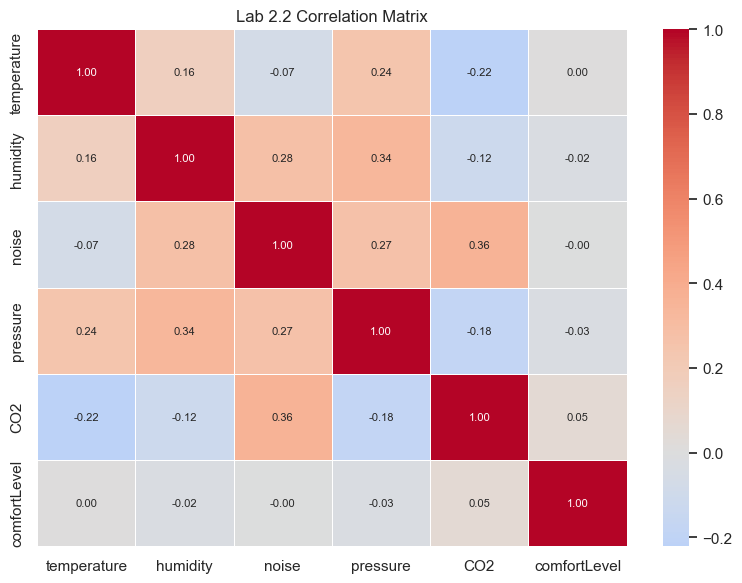

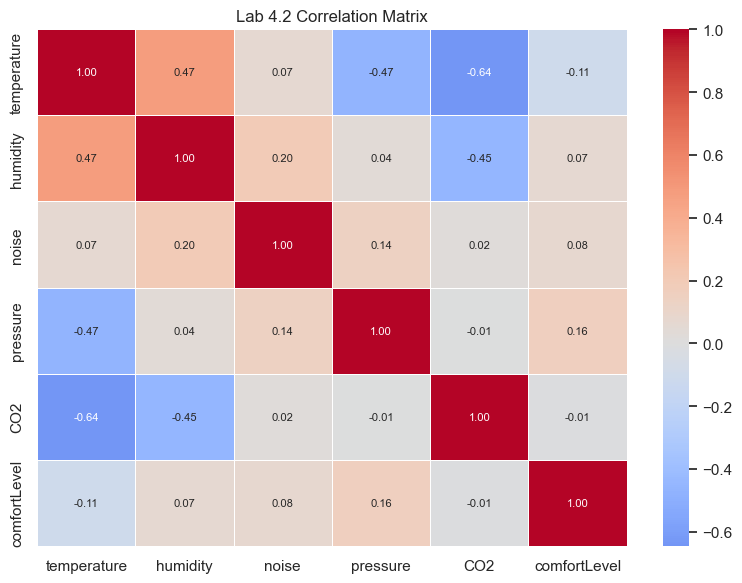

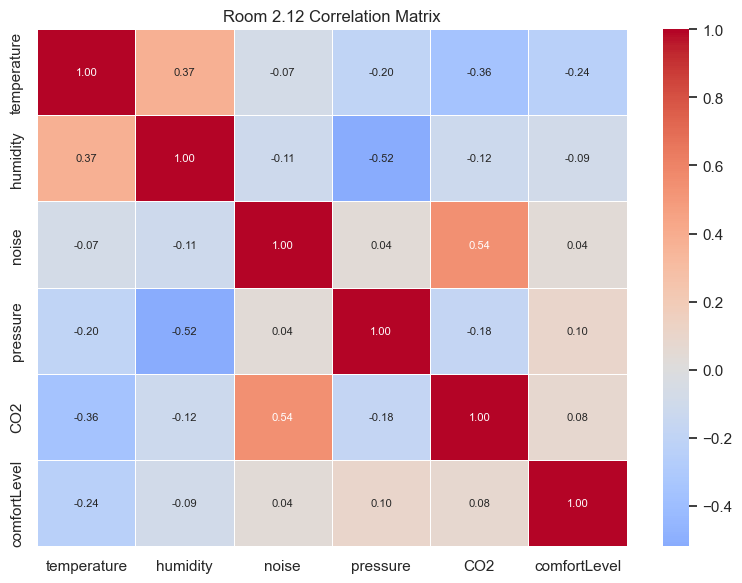

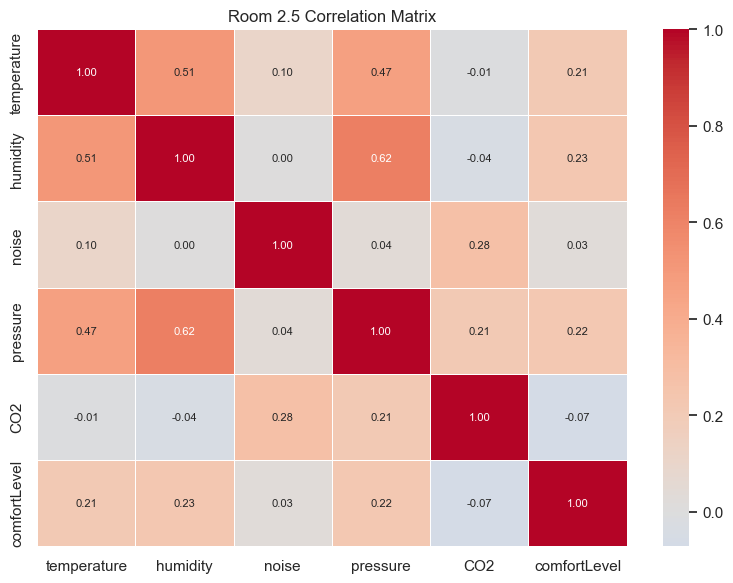

In [28]:
for room_name, room_df in rooms.items():
    numeric_df = room_df.select_dtypes(include=np.number)

    if numeric_df.empty:
        print(f'{room_name} has no numeric columns for correlation.')
        continue

    corr = numeric_df.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
    )
    plt.title(f'{room_name} Correlation Matrix')
    plt.tight_layout()
    plt.show()


## Numeric Feature Comparison


In [29]:
numeric_summary = []

for room_name, room_df in rooms.items():
    numeric_df = room_df.select_dtypes(include=np.number)

    for column in numeric_df.columns:
        numeric_summary.append({
            'Room': room_name,
            'Feature': column,
            'Min': numeric_df[column].min(),
            'Median': numeric_df[column].median(),
            'Mean': numeric_df[column].mean(),
            'Max': numeric_df[column].max(),
            'Std': numeric_df[column].std(),
        })

numeric_summary = pd.DataFrame(numeric_summary)
display(numeric_summary.sort_values(by=['Feature', 'Room']).reset_index(drop=True))


,Room,Feature,Min,Median,Mean,Max,Std
0,Lab 2.2,CO2,376.0,727.0,720.850722,970.0,111.924291
1,Lab 4.2,CO2,427.0,598.5,600.020979,789.0,83.199441
2,Room 2.12,CO2,419.0,824.0,817.306548,1444.0,135.375279
3,Room 2.5,CO2,389.0,641.0,658.076305,943.0,106.521116
4,Lab 2.2,comfortLevel,1.0,3.0,3.547352,5.0,0.816188
5,Lab 4.2,comfortLevel,1.0,3.0,3.227273,5.0,0.890943
6,Room 2.12,comfortLevel,1.0,3.0,3.322917,5.0,0.911041
7,Room 2.5,comfortLevel,1.0,3.0,3.405622,5.0,0.875362
8,Lab 2.2,humidity,37.0,48.0,48.727127,63.0,5.810736
9,Lab 4.2,humidity,36.0,46.0,47.097902,65.0,5.303180


## Visual Anomaly Detection


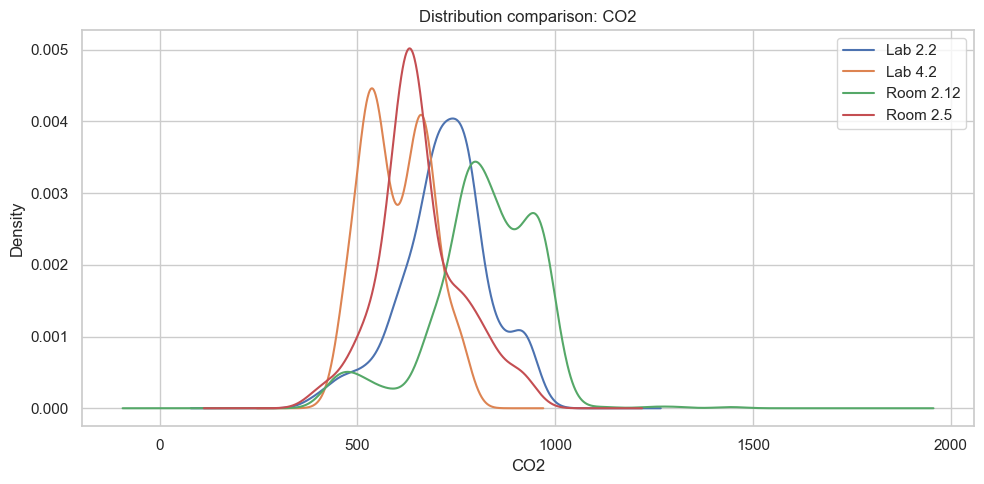

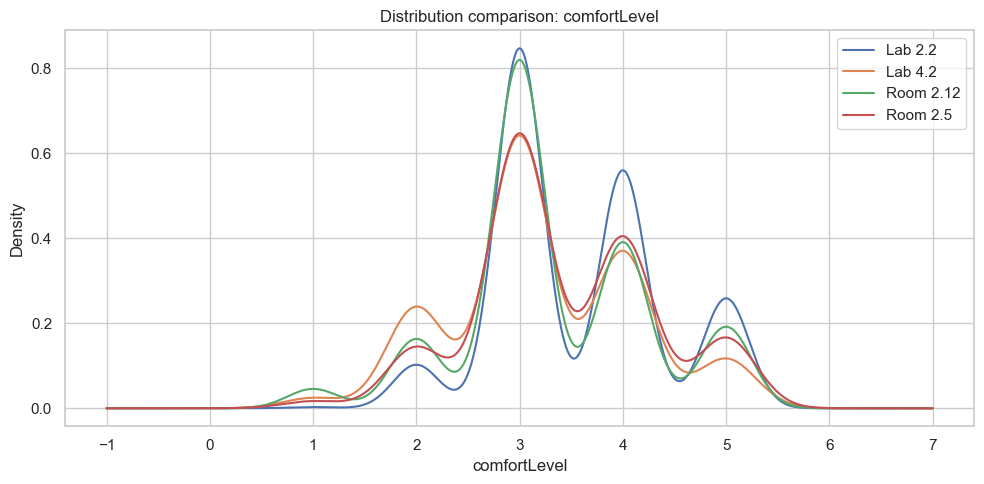

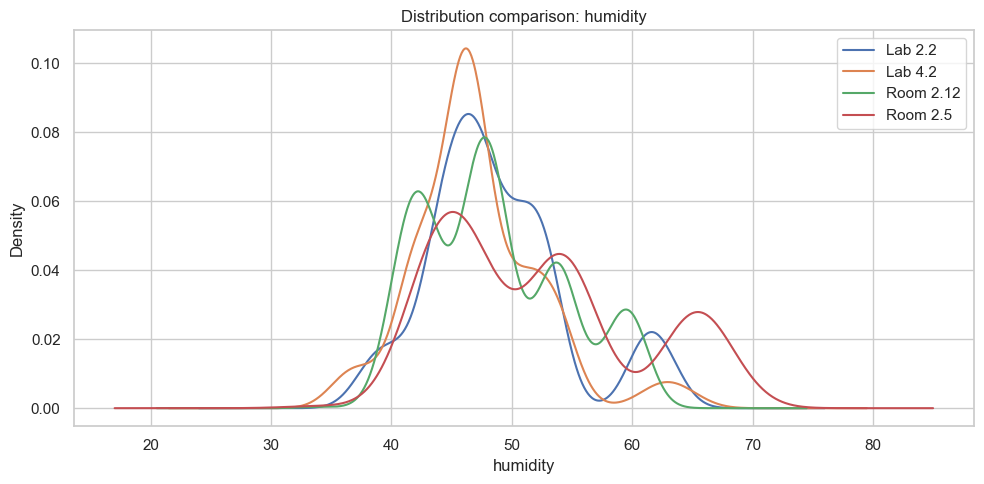

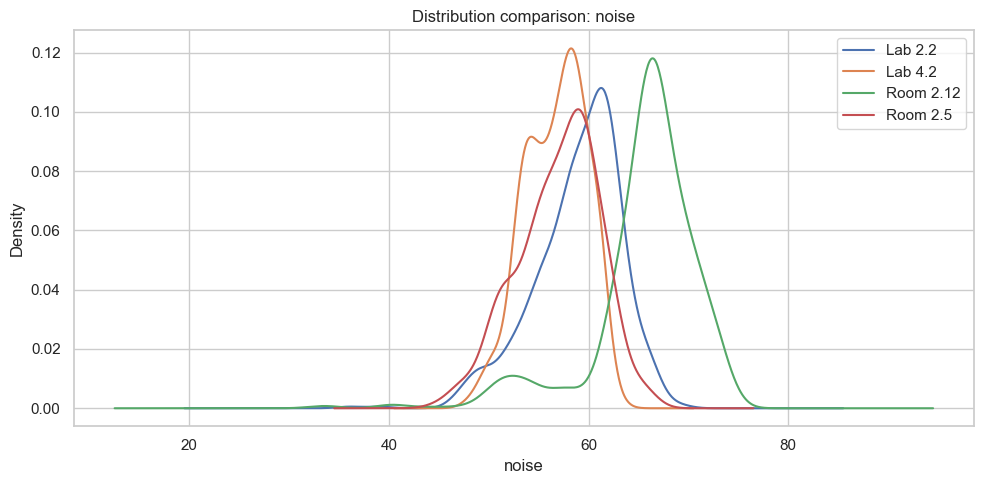

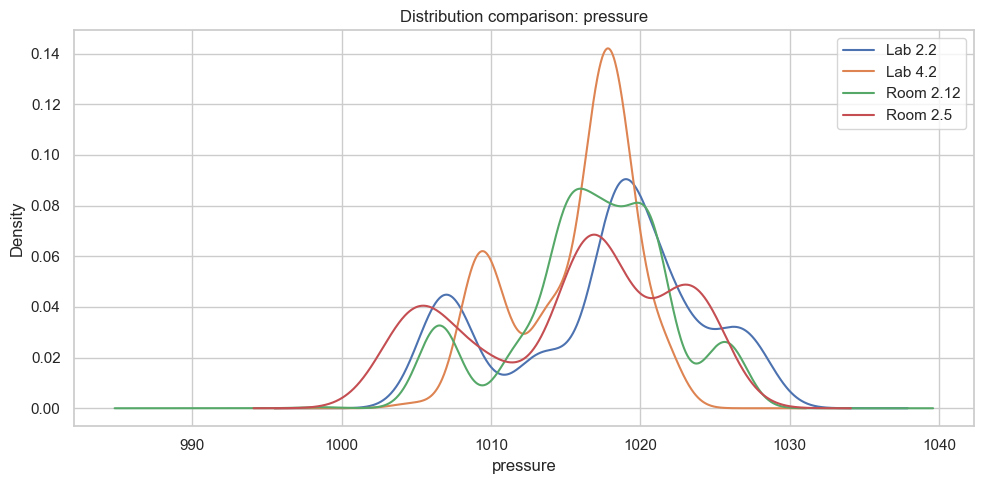

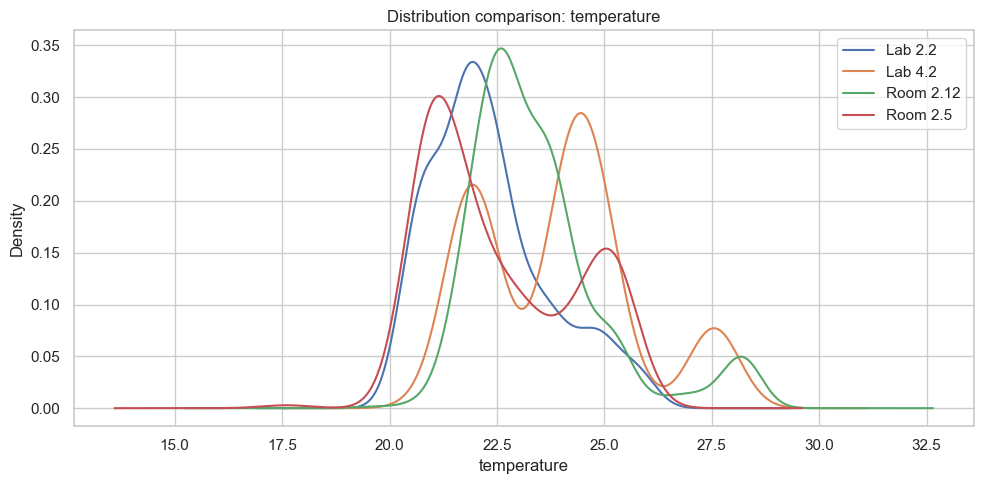

In [30]:
numeric_features = sorted(set(
    column
    for room_df in rooms.values()
    for column in room_df.select_dtypes(include=np.number).columns
))

for feature in numeric_features:
    plt.figure(figsize=(10, 5))

    found = False

    for room_name, room_df in rooms.items():
        if feature in room_df.columns:
            room_df[feature].dropna().plot(kind='kde', label=room_name)
            found = True

    if found:
        plt.title(f'Distribution comparison: {feature}')
        plt.xlabel(feature)
        plt.legend()
        plt.tight_layout()
        plt.show()


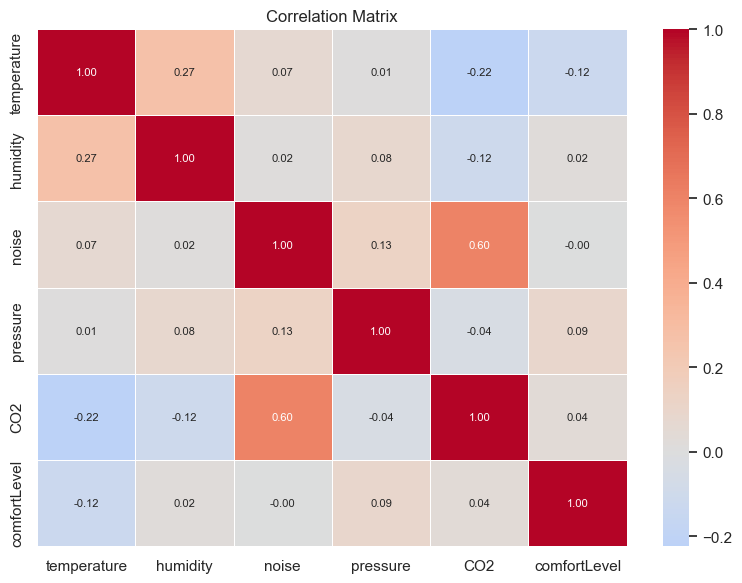

In [ ]:
#correlation matrix of 1_room_measurements_with_comfort.csv (skip timestamp and sensorId and labId columns)

df = pd.read_csv('../../data/processed/1_room_measurements_with_comfort.csv')
df = df.drop(columns=['timestamp', 'sensorId', 'room'])

corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show() 
